# DeepPermNet: Visual Permutation Learning

[cite_start]Welcome to this Jupyter Notebook, dedicated to simulating and reproducing the core concepts from the paper: **[DeepPermNet: Visual Permutation Learning](https://arxiv.org/abs/1704.02729)** by Rodrigo Santa Cruz, Basura Fernando, Anoop Cherian, and Stephen Gould[cite: 13].

## 📖 Paper Overview
Visual data contains rich spatial and temporal structure. This paper introduces a principled approach to uncover this structure by solving a novel deep learning task: **Visual Permutation Learning**. The primary objective is to find the permutation matrix that can recover the original structure of data from its shuffled versions (e.g., reassembling a natural image from scrambled image patches).

Since standard permutation matrices are discrete and difficult to optimize with gradient-based methods, the authors propose **DeepPermNet**[cite: 16, 18]. This end-to-end Convolutional Neural Network (CNN) approximates these matrices using a continuous **Sinkhorn layer**, which generates doubly-stochastic matrices via Sinkhorn iterations to enable efficient backpropagation[cite: 17, 18].

## 🎯 Notebook Objectives
In this notebook, we will:
1. **Prepare the data**: use mini-imagenet to construct for the dataset for the following training process.
2. **Understand the Architecture:** Build the Siamese-style CNN that extracts features from permuted image sequences[cite: 259, 273].
3. **Implement the Sinkhorn Layer:** Create the custom differentiable layer that repeatedly performs row and column normalizations to approximate permutation matrices[cite: 286, 287].
4. **Train the Model:** Use a lightweight dataset to train the network in a self-supervised manner, utilizing spatial layout as the supervisory signal[cite: 490].
5. **Evaluate:** Visualize the model's ability to predict the correct permutation and "un-shuffle" patches to recover the original image layout.



# Data preparation

While the original paper relies on datasets like the *Public Figures dataset*, *OSR scene dataset*, and the massive full *ImageNet* for various tasks, we will utilize a smaller, memory-friendly variant like **Mini-ImageNet** (via `timm/mini-imagenet`). This ensures the notebook runs smoothly in compute-constrained environments like Google Colab while maintaining enough complexity for robust self-supervised representation learning.

## Load data

In [ ]:
import os
access_token = ""
HF_TOKEN = access_token

# Add your Hugging Face token from environment variable
HF_TOKEN = os.getenv("HF_TOKEN", "")
os.environ["HF_TOKEN"] = HF_TOKEN

In [ ]:
from datasets import load_dataset

ds = load_dataset("timm/mini-imagenet")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

data/train-00000-of-00013.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00001-of-00013.parquet:   0%|          | 0.00/361M [00:00<?, ?B/s]

data/train-00002-of-00013.parquet:   0%|          | 0.00/410M [00:00<?, ?B/s]

...

data/test-00000-of-00002.parquet:   0%|          | 0.00/326M [00:00<?, ?B/s]

data/test-00001-of-00002.parquet:   0%|          | 0.00/336M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

--- Dataset Dictionary Structure ---
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 50000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 5000
    })
})

--- Features in the Training Split ---
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['n01532829', 'n01558993', 'n01704323', 'n01749939', 'n01770081', 'n01843383', 'n01855672', 'n01910747', 'n01930112', 'n01981276', 'n02074367', 'n02089867', 'n02091244', 'n02091831', 'n02099601', 'n02101006', 'n02105505', 'n02108089', 'n02108551', 'n02108915', 'n02110063', 'n02110341', 'n02111277', 'n02113712', 'n02114548', 'n02116738', 'n02120079', 'n02129165', 'n02138441', 'n02165456', 'n02174001', 'n02219486', 'n02443484', 'n02457408', 'n02606052', 'n02687172', 'n02747177', 'n02795169', 'n02823428', 'n02871525', 'n02950826', 'n02966193', 'n02971356', 'n0298

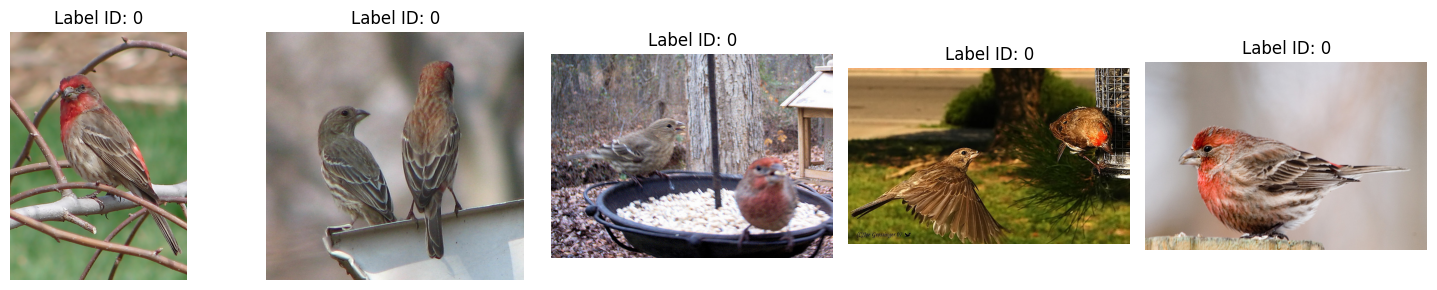

In [ ]:
import matplotlib.pyplot as plt

print("--- Dataset Dictionary Structure ---")
print(ds)

# Let's look specifically at the 'train' split
train_ds = ds['train']
print("\n--- Features in the Training Split ---")
print(train_ds.features)

# Showcase sample images
num_samples = 5
# Create a figure with 1 row and 5 columns
fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for i in range(num_samples):
    # Extract the PIL image and the label from the dataset
    img = train_ds[i]['image']
    label_id = train_ds[i]['label']

    # Plot the image
    axes[i].imshow(img)
    axes[i].set_title(f"Label ID: {label_id}")
    axes[i].axis('off') # Hide the axes for a cleaner look

plt.tight_layout()
plt.show()

## Shuffling

In this section, we construct the self-supervised dataset required to train **DeepPermNet**. Since our goal is to teach the model to "un-shuffle" images, we don't need traditional class labels. Instead, we use the inherent spatial structure of the images themselves.

Using **PyTorch Lightning**, we build a robust data pipeline that performs the following steps on the fly for every image in the Mini-ImageNet dataset:

1. **Resize & Normalize:** Each image is resized to $192 \times 192$ pixels to ensure uniform dimensions.
2. **Grid Splitting:** The image is divided into a $3 \times 3$ grid, extracting nine $64 \times 64$ pixel patches.
3. **Random Permutation (The Shuffle):** A random sequence (from 0 to 8) is generated and used to shuffle the spatial order of the nine patches.
4. **Target Generation:** The shuffled patches become our input features ($X$), and the specific permutation array used to shuffle them becomes our target label ($Y$).

By the end of this section, we will have a fully functional `LightningDataModule` ready to feed batches of scrambled image patches into our neural network.

In [ ]:
import torch
import pytorch_lightning as pl
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import random
from datasets import load_dataset
import matplotlib.pyplot as plt

class DeepPermNetDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset

        # To perfectly simulate the 3x3 grid of 64x64 patches,
        # we ensure the base image is 192x192 pixels.
        self.base_transform = transforms.Compose([
            transforms.Resize((192, 192)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        # 1. Get image and ensure it's RGB
        img = self.hf_dataset[idx]['image']
        if img.mode != 'RGB':
            img = img.convert('RGB')

        # 2. Apply base transform to get a 3x192x192 tensor
        img_tensor = self.base_transform(img)

        # 3. Extract the 3x3 grid of 64x64 patches
        # We use tensor unfolding to cleanly slice the image into patches
        # Shape: (Channels, Grid_H, Grid_W, Patch_H, Patch_W) -> (3, 3, 3, 64, 64)
        patches = img_tensor.unfold(1, 64, 64).unfold(2, 64, 64)

        # Reshape to get a sequence of 9 patches: shape (9, 3, 64, 64)
        patches = patches.contiguous().view(3, -1, 64, 64).permute(1, 0, 2, 3)

        # 4. Generate a random permutation for the 9 patches
        permutation = list(range(9))
        random.shuffle(permutation)

        # 5. Shuffle the patches according to the permutation
        shuffled_patches = patches[permutation]

        # Convert permutation to a tensor (this is our training target)
        target_permutation = torch.tensor(permutation, dtype=torch.long)

        return shuffled_patches, target_permutation

class DeepPermNetDataModule(pl.LightningDataModule):
    def __init__(self, dataset_name="timm/mini-imagenet", batch_size=32):
        super().__init__()
        self.dataset_name = dataset_name
        self.batch_size = batch_size

    def setup(self, stage=None):
        # Load the HuggingFace dataset
        ds = load_dataset(self.dataset_name)

        # Create PyTorch datasets for training and validation
        self.train_dataset = DeepPermNetDataset(ds['train'])
        self.val_dataset = DeepPermNetDataset(ds['validation'])

    def train_dataloader(self):
        # The num_workers can be adjusted based on your Colab environment
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=2)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=2)

## Visualizing the Output of the Pipeline

In [ ]:
import torchvision.transforms.functional as F

# Initialize and setup the DataModule
data_module = DeepPermNetDataModule(batch_size=1)
data_module.setup()

# Grab one batch from the training dataloader
train_loader = data_module.train_dataloader()
shuffled_patches, target_permutation = next(iter(train_loader))

# Squeeze out the batch dimension
shuffled_patches = shuffled_patches.squeeze(0)
target_permutation = target_permutation.squeeze(0)

# Plot the 9 shuffled patches
print(f"Target Permutation (Indices): {target_permutation.tolist()}")

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
axes = axes.flatten()

for i in range(9):
    # Convert tensor patch back to PIL image for plotting
    patch_img = F.to_pil_image(shuffled_patches[i])
    axes[i].imshow(patch_img)
    axes[i].axis('off')
    axes[i].set_title(f"Patch {i}")

plt.suptitle("Shuffled Image Patches (Network Input)", fontsize=16)
plt.tight_layout()
plt.show()

# Training

The training phase of **DeepPermNet** teaches the model to deduce the exact sequence used to shuffle the image patches. Because the network must predict a mathematical permutation, the architecture relies on two specialized components:

### 1. The Siamese Feature Extractor
The core architecture is a **shared-weight Convolutional Neural Network (CNN)**. Instead of looking at the whole shuffled image at once, the network processes each of the 9 patches independently through the exact same convolutional layers (a Siamese architecture). This forces the network to learn robust, universal patch features. Once the features for all 9 patches are extracted, they are flattened, concatenated, and passed through fully connected (dense) layers to output a raw $9 \times 9$ matrix of predictions.

### 2. The Differentiable Sinkhorn Layer
The biggest challenge in this task is that standard permutation matrices are discrete (strict grids of 0s and 1s), making them impossible to optimize using standard gradient descent.

To bridge this gap, the network passes its raw $9 \times 9$ output through a custom **Sinkhorn Layer**. This layer applies the Sinkhorn algorithm, which repeatedly normalizes the rows and columns of the matrix. After several iterations, this forces the output to become a **doubly-stochastic matrix** (a continuous matrix where every row and column naturally sums to 1).

### Optimization
Because the Sinkhorn layer provides a continuous, differentiable approximation of a permutation, we can train the entire network end-to-end. We calculate the **Mean Squared Error (MSE) loss** between the network's continuous doubly-stochastic output and the ground-truth 1/0 permutation matrix, allowing PyTorch Lightning to update the weights via standard backpropagation.

## The Sinkhorn Layer Implementation

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint

def sinkhorn_operator(log_alpha, n_iters=20):
    """
    Applies the Sinkhorn iterations to a matrix to approximate a permutation matrix.
    It repeatedly normalizes the rows and columns.
    """
    # Exponentiate to ensure all values are positive
    P = torch.exp(log_alpha)

    # Iterate to normalize rows and columns
    for _ in range(n_iters):
        P = P / P.sum(dim=2, keepdim=True) # Normalize rows
        P = P / P.sum(dim=1, keepdim=True) # Normalize columns
    return P



## PyTorch Lightning Model Definition

In [ ]:
class DeepPermNet(pl.LightningModule):
    def __init__(self, learning_rate=1e-4):
        super().__init__()
        self.save_hyperparameters()
        self.learning_rate = learning_rate

        # A lightweight CNN Feature Extractor for 64x64 patches
        # Output of this will be a flattened vector for each patch
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 32x32
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 16x16
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 8x8
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 4x4
            nn.Flatten() # Resulting feature size: 128 * 4 * 4 = 2048
        )

        # Fully Connected Network to predict the permutation matrix
        # Input is 9 patches * 2048 features = 18432
        # Output is a 9x9 matrix (flattened to 81)
        self.fc_layers = nn.Sequential(
            nn.Linear(9 * 2048, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 9 * 9)
        )

    def forward(self, x):
        # x shape: (Batch, 9, 3, 64, 64)
        batch_size = x.size(0)

        # We need to process each of the 9 patches through the SAME CNN.
        # To do this efficiently, we merge the Batch and Sequence dimensions
        x_reshaped = x.view(-1, 3, 64, 64) # Shape: (Batch * 9, 3, 64, 64)

        # Extract features
        features = self.feature_extractor(x_reshaped) # Shape: (Batch * 9, 2048)

        # Reshape back to separate the 9 patches per batch item
        features = features.view(batch_size, -1) # Shape: (Batch, 9 * 2048)

        # Predict the unnormalized 9x9 matrix
        matrix_logits = self.fc_layers(features)
        matrix_logits = matrix_logits.view(batch_size, 9, 9)

        # Apply the Sinkhorn layer to approximate a discrete permutation matrix
        predicted_permutation = sinkhorn_operator(matrix_logits)

        return predicted_permutation

    def calculate_loss(self, predicted_matrix, target_indices):
        # target_indices shape: (Batch, 9) containing values 0-8.
        # We convert these index sequences into actual 9x9 one-hot permutation matrices.
        target_matrix = F.one_hot(target_indices, num_classes=9).float()

        # We use Mean Squared Error (MSE) to compare the predicted doubly-stochastic
        # matrix against the hard one-hot ground truth matrix.
        loss = F.mse_loss(predicted_matrix, target_matrix)
        return loss

    def training_step(self, batch, batch_idx):
        shuffled_patches, target_permutation = batch
        predicted_matrix = self(shuffled_patches)

        loss = self.calculate_loss(predicted_matrix, target_permutation)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        shuffled_patches, target_permutation = batch
        predicted_matrix = self(shuffled_patches)

        loss = self.calculate_loss(predicted_matrix, target_permutation)
        self.log('val_loss', loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)



## Training Launch

In [ ]:

# 1. Initialize the DataModule (from your previous code)
# Using a smaller batch size to prevent Colab RAM/VRAM issues
data_module = DeepPermNetDataModule(batch_size=16)

# 2. Initialize the Model
model = DeepPermNet(learning_rate=1e-4)

# 3. Setup PyTorch Lightning Trainer
# We use fast_dev_run=False. If you want to just test if it compiles and runs
# for 1 batch, change fast_dev_run=True.
trainer = Trainer(
    max_epochs=5,           # Train for 5 epochs to start
    accelerator='auto',     # Automatically uses GPU if available in Colab
    devices=1,
    log_every_n_steps=10    # Update the progress bar frequently
)

# 4. Start Training!
print("Starting DeepPermNet Training...")
trainer.fit(model, datamodule=data_module)